In [2]:
import matplotlib.font_manager as fm
from matplotlib import rcParams

font_path = '/home/shariat/Documents/fonts/Helvetica.ttf'
fm.fontManager.addfont(font_path)           # add it globally
rcParams['font.family'] = 'Helvetica'  # set default

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    accuracy_score
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [4]:
# ────────────────────────────────────────────────
#                Data Loading & Preparation
# ────────────────────────────────────────────────

data = pd.read_csv('/home/shariat/Astronomy/TTV/Data/PS_2025.10.03_12.37.12.csv', comment='#')

features = [
    'pl_orbper', 'pl_orbsmax', 'pl_rade', 'pl_masse', 'pl_orbeccen',
    'pl_insol', 'pl_eqt', 'pl_orbincl', 'pl_trandep', 'pl_trandur',
    'pl_ratdor', 'pl_ratror', 'st_teff', 'st_rad', 'st_mass'
]
target = 'ttv_flag'

kepler_k2_data = data[data['disc_facility'].isin(['Kepler', 'K2'])].copy()
kepler_k2_data = kepler_k2_data.dropna(subset=[target])

print(f"Kepler + K2 rows: {len(kepler_k2_data)}")
print("Class distribution BEFORE processing:")
print(kepler_k2_data[target].value_counts())
print(kepler_k2_data[target].value_counts(normalize=True).round(4))

# Median imputation for missing values
for col in features:
    if col in kepler_k2_data.columns:
        kepler_k2_data[col] = kepler_k2_data[col].fillna(kepler_k2_data[col].median())

X = kepler_k2_data[features].values
y = kepler_k2_data[target].values.astype(int)

scaler = StandardScaler()
X = scaler.fit_transform(X)


Kepler + K2 rows: 30654
Class distribution BEFORE processing:
ttv_flag
0.0    25810
1.0     4844
Name: count, dtype: int64
ttv_flag
0.0    0.842
1.0    0.158
Name: proportion, dtype: float64


In [5]:
# ────────────────────────────────────────────────
#          Experiment Settings – CHANGE HERE
# ────────────────────────────────────────────────

experiment_name   = "dt_3fold_gini_smote_balanced"
use_smote         = True
use_class_weight  = True

param_grid = {
    'criterion': ['gini'],
    'max_depth': [None],                  # None = unlimited depth
    'min_samples_split': [5],
    'min_samples_leaf': [2],
    'class_weight': ['balanced'] if use_class_weight else [None]
}


In [6]:
# ────────────────────────────────────────────────
#               10-Fold Cross-Validation
# ────────────────────────────────────────────────

n_splits = 20
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

accuracy_scores  = []
precision_scores = []
recall_scores    = []
f1_scores        = []
auc_scores       = []
cm_list          = []
tpr_list         = []
fpr_list         = []

smote = SMOTE(random_state=42, sampling_strategy='auto')

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold+1}/{n_splits}")
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Apply SMOTE only to training data
    if use_smote:
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        print(f" After SMOTE → class counts: {np.bincount(y_train_res)}")
    else:
        X_train_res, y_train_res = X_train, y_train
        print(" No SMOTE applied")

    # GridSearchCV (even with single values it will still run inner CV)
    dt = DecisionTreeClassifier(random_state=42)
    
    grid_search = GridSearchCV(
        estimator=dt,
        param_grid=param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train_res, y_train_res)
    best_model = grid_search.best_estimator_

    # Evaluate on validation fold (never seen during training)
    y_pred = best_model.predict(X_val)
    y_pred_proba = best_model.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    auc = roc_auc_score(y_val, y_pred_proba)

    accuracy_scores.append(acc)
    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)
    auc_scores.append(auc)

    cm_list.append(confusion_matrix(y_val, y_pred))

    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    common_fpr = np.linspace(0, 1, 100)
    tpr_interp = np.interp(common_fpr, fpr, tpr)
    tpr_list.append(tpr_interp)
    fpr_list.append(common_fpr)

    print(f" Acc: {acc:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}")


Fold 1/20
 After SMOTE → class counts: [24519 24519]
 Acc: 0.8858  Prec: 0.6175  Rec: 0.7273  F1: 0.6679  AUC: 0.8560

Fold 2/20
 After SMOTE → class counts: [24519 24519]
 Acc: 0.8741  Prec: 0.5809  Rec: 0.7273  F1: 0.6459  AUC: 0.8353

Fold 3/20
 After SMOTE → class counts: [24519 24519]
 Acc: 0.8930  Prec: 0.6383  Rec: 0.7438  F1: 0.6870  AUC: 0.8614

Fold 4/20
 After SMOTE → class counts: [24519 24519]
 Acc: 0.8793  Prec: 0.5960  Rec: 0.7314  F1: 0.6568  AUC: 0.8376

Fold 5/20
 After SMOTE → class counts: [24519 24519]
 Acc: 0.8885  Prec: 0.6113  Rec: 0.8058  F1: 0.6952  AUC: 0.8854

Fold 6/20
 After SMOTE → class counts: [24519 24519]
 Acc: 0.8865  Prec: 0.6223  Rec: 0.7149  F1: 0.6654  AUC: 0.8398

Fold 7/20
 After SMOTE → class counts: [24519 24519]
 Acc: 0.8793  Prec: 0.5966  Rec: 0.7273  F1: 0.6555  AUC: 0.8485

Fold 8/20
 After SMOTE → class counts: [24519 24519]
 Acc: 0.8728  Prec: 0.5825  Rec: 0.6860  F1: 0.6300  AUC: 0.8256

Fold 9/20
 After SMOTE → class counts: [24519 2

In [7]:
# ────────────────────────────────────────────────
#                  Summary Results
# ────────────────────────────────────────────────

print(f"\n{'═'*70}")
print(f"EXPERIMENT: {experiment_name}")
print(f"SMOTE used: {use_smote} | class_weight='balanced': {use_class_weight}")
print(f"Best params (last fold): {grid_search.best_params_}")
print(f"{'═'*70}")
print(f"Accuracy:  {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall:    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1 Score:  {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"ROC-AUC:   {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"{'═'*70}\n")


══════════════════════════════════════════════════════════════════════
EXPERIMENT: dt_3fold_gini_smote_balanced
SMOTE used: True | class_weight='balanced': True
Best params (last fold): {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}
══════════════════════════════════════════════════════════════════════
Accuracy:  0.8844 ± 0.0077
Precision: 0.6119 ± 0.0233
Recall:    0.7372 ± 0.0302
F1 Score:  0.6683 ± 0.0200
ROC-AUC:   0.8516 ± 0.0160
══════════════════════════════════════════════════════════════════════



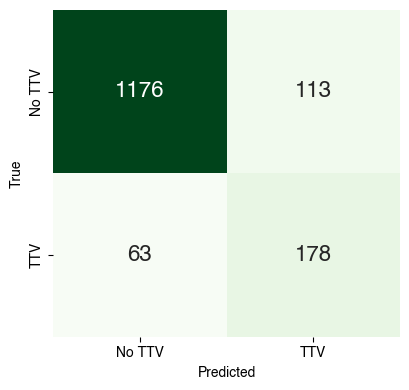

In [8]:
# ────────────────────────────────────────────────
#          Average Confusion Matrix
# ────────────────────────────────────────────────

avg_cm = np.mean(cm_list, axis=0).astype(int)

plt.figure(figsize=(4.2, 4))
sns.heatmap(avg_cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            annot_kws={"size": 16})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks([0.5, 1.5], ['No TTV', 'TTV'])
plt.yticks([0.5, 1.5], ['No TTV', 'TTV'])
#plt.savefig('/home/shariat/Astronomy/TTV/DecisionTree/Kepler/figures/kepler_dt_fold_20_gini_leaf_2_split_5_cm.pdf')
plt.savefig('/home/shariat/Astronomy/TTV/figures/DecisionTree_Kepler_cm.pdf')
plt.show()


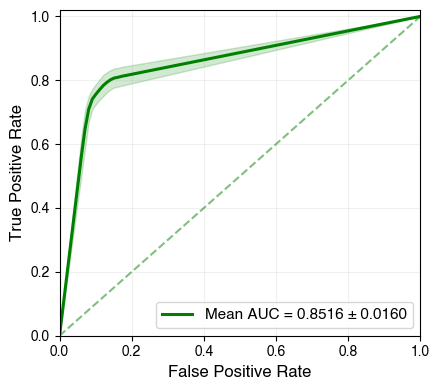

In [9]:
# ────────────────────────────────────────────────
#             Averaged ROC Curve
# ────────────────────────────────────────────────

mean_tpr = np.mean(tpr_list, axis=0)
std_tpr  = np.std(tpr_list, axis=0)
mean_fpr = fpr_list[0]

plt.figure(figsize=(4.5, 4))
plt.plot(mean_fpr, mean_tpr,
         label=f'Mean AUC = {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}',
         color='green', lw=2.2)
plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                 color='green', alpha=0.18)
plt.plot([0, 1], [0, 1], linestyle='--', color='green', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.18)
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.tight_layout()
#plt.savefig('/home/shariat/Astronomy/TTV/DecisionTree/Kepler/figures/kepler_dt_fold_20_gini_leaf_2_roc_split_5.pdf')
plt.savefig('/home/shariat/Astronomy/TTV/figures/DecisionTree_Kepler_roc.pdf')
plt.show()